## Raceline Analysis

Analyze lap-time and raceline differences between Gymkhana MPC expert trajectories and ROS LSTM trajectories.

Expected data root: `LSTM_training/data/raceline_validation_data`

The main comparison uses canonical map names so differently named folders such as `brandhatch` and `mexico city` can be matched to their MPC baselines.


## Setup


In [1]:
import os
import re
import zipfile
from pathlib import Path

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from scipy.spatial import cKDTree

sns.set_theme(style="whitegrid")

BASE_DIR = Path("../../data/raceline_validation_data").resolve()
MPC_DIR = BASE_DIR / "MPC (gymkhana)"
LSTM_DIR = BASE_DIR / "LSTM (ROS)"

CANONICAL_MAP_ALIASES = {
    "brandhatch": "brandshatch",
    "brands hatch": "brandshatch",
    "brandshatch": "brandshatch",
    "drift": "drift2",
    "drift2": "drift2",
    "ims": "ims",
    "mexico city": "mexicocity",
    "mexicocity": "mexicocity",
    "spielberg": "spielberg",
}

MAP_DISPLAY_NAMES = {
    "brandshatch": "Brands Hatch",
    "drift2": "Drift 2",
    "ims": "IMS",
    "mexicocity": "Mexico City",
    "spielberg": "Spielberg",
}

print(f"Base directory: {BASE_DIR}")
print(f"Base directory exists: {BASE_DIR.exists()}")


Base directory: /home/henry/Documents/Coursework/f1_16663/external/ApproxiMPC/LSTM_training/data/raceline_validation_data
Base directory exists: True


In [2]:
def normalize_text(value):
    """Normalize path/name fragments for matching."""
    text = str(value).lower().replace("_", " ").replace("-", " ")
    return re.sub(r"\s+", " ", text).strip()


def canonical_map_name(value):
    """Return the canonical map name used for joins and comparisons."""
    text = normalize_text(value)
    if text in CANONICAL_MAP_ALIASES:
        return CANONICAL_MAP_ALIASES[text]

    compact = text.replace(" ", "")
    return CANONICAL_MAP_ALIASES.get(compact, text)


def display_map_name(map_norm):
    return MAP_DISPLAY_NAMES.get(map_norm, str(map_norm).title())


def get_actual_key(data, target_substring):
    """Find an npz key even if it has trailing spaces."""
    for key in data.files:
        if target_substring in key.strip():
            return key
    raise KeyError(f"Could not find key containing {target_substring!r}")


def extract_sequence_size(file_path):
    """Extract sequence length from known model filename patterns without capturing dates."""
    name = file_path.stem.lower()
    patterns = [
        r"(?:seq_?lstm|seqlst|lstm)_(\d+)",
        r"(?<!\d)(\d+)d\b",
    ]
    for pattern in patterns:
        match = re.search(pattern, name)
        if match:
            return int(match.group(1))
    return np.nan


def infer_lstm_map(file_path):
    """Infer the map from the folder layout, restricted to known comparable maps."""
    path_parts = [normalize_text(part) for part in file_path.parts]
    if "old" in path_parts:
        return None

    parent_map = canonical_map_name(file_path.parent.name)
    if parent_map in MAP_DISPLAY_NAMES:
        return parent_map

    # Top-level loose files are not part of the current comparable raceline set.
    return None


## Build Dataset Catalog


In [3]:
records = []
skipped_files = []

if MPC_DIR.exists():
    for file_path in sorted(MPC_DIR.glob("stmpc_*.npz")):
        raw_map = file_path.stem.split("_")[1]
        map_norm = canonical_map_name(raw_map)
        records.append({
            "algorithm": "MPC",
            "model_type": "gymkhana",
            "map": raw_map.lower(),
            "map_norm": map_norm,
            "map_display": display_map_name(map_norm),
            "size": np.nan,
            "filepath": file_path,
        })

if LSTM_DIR.exists():
    for file_path in sorted(LSTM_DIR.rglob("*.npz")):
        parts = set(file_path.parts)
        if "curvature lstm" in parts:
            model_type = "curvature"
        elif "mapless lstm" in parts:
            model_type = "mapless"
        else:
            model_type = "unknown"

        map_norm = infer_lstm_map(file_path)
        if map_norm is None:
            skipped_files.append(file_path)
            continue

        records.append({
            "algorithm": "LSTM",
            "model_type": model_type,
            "map": file_path.parent.name.lower(),
            "map_norm": map_norm,
            "map_display": display_map_name(map_norm),
            "size": extract_sequence_size(file_path),
            "filepath": file_path,
        })

df_experiments = pd.DataFrame(records)

print(f"Cataloged {len(df_experiments)} comparable datasets.")
print(f"Skipped {len(skipped_files)} non-comparable or archived LSTM files.")
display(df_experiments[["algorithm", "model_type", "map_display", "size", "filepath"]])

if skipped_files:
    skipped_df = pd.DataFrame({"skipped_filepath": skipped_files})
    display(skipped_df)


Cataloged 26 comparable datasets.
Skipped 9 non-comparable or archived LSTM files.


,algorithm,model_type,map_display,size,filepath
0,MPC,gymkhana,Brands Hatch,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
1,MPC,gymkhana,Drift 2,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
2,MPC,gymkhana,IMS,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
3,MPC,gymkhana,Mexico City,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
4,MPC,gymkhana,Spielberg,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
5,LSTM,curvature,Drift 2,128.0,/home/henry/Documents/Coursework/f1_16663/exte...
6,LSTM,curvature,Drift 2,196.0,/home/henry/Documents/Coursework/f1_16663/exte...
7,LSTM,curvature,Drift 2,96.0,/home/henry/Documents/Coursework/f1_16663/exte...
8,LSTM,curvature,IMS,96.0,/home/henry/Documents/Coursework/f1_16663/exte...
9,LSTM,curvature,IMS,128.0,/home/henry/Documents/Coursework/f1_16663/exte...


,skipped_filepath
0,/home/henry/Documents/Coursework/f1_16663/exte...
1,/home/henry/Documents/Coursework/f1_16663/exte...
2,/home/henry/Documents/Coursework/f1_16663/exte...
3,/home/henry/Documents/Coursework/f1_16663/exte...
4,/home/henry/Documents/Coursework/f1_16663/exte...
5,/home/henry/Documents/Coursework/f1_16663/exte...
6,/home/henry/Documents/Coursework/f1_16663/exte...
7,/home/henry/Documents/Coursework/f1_16663/exte...
8,/home/henry/Documents/Coursework/f1_16663/exte...


## Schema Checks


In [4]:
def inspect_npz_schema(filepath, tag=""):
    print(f"--- Schema Inspection: {tag} ---")
    print(f"File: {filepath.name}")
    try:
        with np.load(filepath, allow_pickle=True) as data:
            for key in data.files:
                arr = data[key]
                print(f"  Key: {key!r:<20} Shape: {str(arr.shape):<15} Type: {arr.dtype}")
    except zipfile.BadZipFile:
        print("  Corrupt .npz file")
    except Exception as exc:
        print(f"  Error: {exc}")
    print()

mpc_sample = df_experiments[df_experiments["algorithm"] == "MPC"]["filepath"].iloc[0]
lstm_sample = df_experiments[df_experiments["algorithm"] == "LSTM"]["filepath"].iloc[0]

inspect_npz_schema(mpc_sample, "Gymkhana MPC")
inspect_npz_schema(lstm_sample, "ROS LSTM")


--- Schema Inspection: Gymkhana MPC ---
File: stmpc_BrandsHatch_normal.npz
  Key: 'observations'       Shape: (25523, 5)      Type: float32
  Key: 'next_observations'  Shape: (25523, 5)      Type: float32
  Key: 'expert_actions'     Shape: (25523, 2)      Type: float32
  Key: 'executed_actions'   Shape: (25523, 2)      Type: float32
  Key: 'rewards'            Shape: (25523,)        Type: float32
  Key: 'terminations'       Shape: (25523,)        Type: bool
  Key: 'truncations'        Shape: (25523,)        Type: bool
  Key: 'is_perturbed'       Shape: (25523,)        Type: bool
  Key: 'collector_lap_counts' Shape: (25523,)        Type: int32
  Key: 'env_lap_counts'     Shape: (25523,)        Type: int32
  Key: 'collision_flags'    Shape: (25523,)        Type: bool
  Key: 'boundary_flags'     Shape: (25523,)        Type: bool
  Key: 'episode_ids'        Shape: (25523,)        Type: int32
  Key: 'step_ids'           Shape: (25523,)        Type: int32
  Key: 'feature_names'      Shape: (

## Lap Times


In [5]:
def get_lstm_lap_time(filepath):
    try:
        if os.path.getsize(filepath) == 0:
            return "Empty File"

        with np.load(filepath, allow_pickle=True) as data:
            timestamps = data[get_actual_key(data, "timestamps")]
            left_start = data[get_actual_key(data, "has_left_start_zone")]
            completed = data[get_actual_key(data, "completion_flag")]

            left_indices = np.where(left_start == 1)[0]
            completion_indices = np.where(completed == 1)[0]
            if left_indices.size == 0 or completion_indices.size == 0:
                return "Incomplete"

            start_idx = left_indices[0]
            valid_completion_indices = completion_indices[completion_indices > start_idx]
            if valid_completion_indices.size == 0:
                return "Incomplete"

            end_idx = valid_completion_indices[0]
            return float(timestamps[end_idx] - timestamps[start_idx])

    except zipfile.BadZipFile:
        return "Corrupt .npz"
    except Exception as exc:
        return f"Error: {exc}"


def get_mpc_lap_time(filepath):
    """Use recording duration for MPC runs; Gymkhana logs are sampled at 100 Hz."""
    try:
        with np.load(filepath, allow_pickle=True) as data:
            lap_counts = data[get_actual_key(data, "env_lap_counts")]
            if len(lap_counts) < 100:
                return "Too Short"
            return float(len(lap_counts) * 0.01)
    except zipfile.BadZipFile:
        return "Corrupt .npz"
    except Exception as exc:
        return f"Error: {exc}"


def process_lap_time(row):
    if row["algorithm"] == "MPC":
        return get_mpc_lap_time(row["filepath"])
    return get_lstm_lap_time(row["filepath"])


df_experiments["lap_time_raw"] = df_experiments.apply(process_lap_time, axis=1)
df_experiments["lap_time"] = pd.to_numeric(df_experiments["lap_time_raw"], errors="coerce")
df_experiments["status"] = np.where(df_experiments["lap_time"].notna(), "Success", df_experiments["lap_time_raw"])

display(
    df_experiments[
        ["algorithm", "model_type", "map_display", "size", "status", "lap_time", "filepath"]
    ].sort_values(["status", "map_display", "algorithm", "model_type", "size"])
)


,algorithm,model_type,map_display,size,status,lap_time,filepath
7,LSTM,curvature,Drift 2,96.0,Corrupt .npz,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
23,LSTM,mapless,Drift 2,64.0,Corrupt .npz,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
21,LSTM,mapless,Brands Hatch,64.0,Incomplete,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
20,LSTM,mapless,Brands Hatch,128.0,Incomplete,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
22,LSTM,mapless,Drift 2,128.0,Incomplete,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
25,LSTM,mapless,IMS,64.0,Incomplete,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
11,LSTM,curvature,Spielberg,196.0,Incomplete,NaN,/home/henry/Documents/Coursework/f1_16663/exte...
16,LSTM,curvature,Brands Hatch,96.0,Success,214.769554,/home/henry/Documents/Coursework/f1_16663/exte...
14,LSTM,curvature,Brands Hatch,128.0,Success,210.385500,/home/henry/Documents/Coursework/f1_16663/exte...
15,LSTM,curvature,Brands Hatch,196.0,Success,224.443425,/home/henry/Documents/Coursework/f1_16663/exte...


In [6]:
status_summary = (
    df_experiments
    .groupby(["algorithm", "status"])
    .size()
    .rename("count")
    .reset_index()
    .sort_values(["algorithm", "status"])
)

map_coverage = (
    df_experiments
    .pivot_table(index="map_display", columns="algorithm", values="filepath", aggfunc="count", fill_value=0)
    .reset_index()
)

print("Status summary")
display(status_summary)
print("Map coverage")
display(map_coverage)


Status summary


,algorithm,status,count
0,LSTM,Corrupt .npz,2
1,LSTM,Incomplete,5
2,LSTM,Success,14
3,MPC,Success,5


Map coverage


algorithm,map_display,LSTM,MPC
0,Brands Hatch,5,1
1,Drift 2,5,1
2,IMS,5,1
3,Mexico City,3,1
4,Spielberg,3,1


## Performance Comparison


In [7]:
successful_runs = df_experiments[df_experiments["status"] == "Success"].copy()

comparison_df = (
    successful_runs
    .groupby(["map_norm", "map_display", "algorithm"], as_index=False)["lap_time"]
    .min()
    .pivot(index=["map_norm", "map_display"], columns="algorithm", values="lap_time")
    .reset_index()
)
comparison_df["delta_sec"] = comparison_df["MPC"] - comparison_df["LSTM"]
comparison_df["improvement_pct"] = comparison_df["delta_sec"] / comparison_df["MPC"] * 100
comparison_df = comparison_df.sort_values("map_display")

print("Best successful lap time by map")
display(
    comparison_df[["map_display", "MPC", "LSTM", "delta_sec", "improvement_pct"]]
    .style.format({"MPC": "{:.2f}s", "LSTM": "{:.2f}s", "delta_sec": "{:.2f}s", "improvement_pct": "{:.1f}%"})
)


Best successful lap time by map


algorithm,map_display,MPC,LSTM,delta_sec,improvement_pct
0,Brands Hatch,255.23s,210.39s,44.84s,17.6%
1,Drift 2,38.38s,37.27s,1.11s,2.9%
2,IMS,206.83s,57.36s,149.47s,72.3%
3,Mexico City,259.09s,212.94s,46.15s,17.8%
4,Spielberg,247.87s,211.83s,36.04s,14.5%


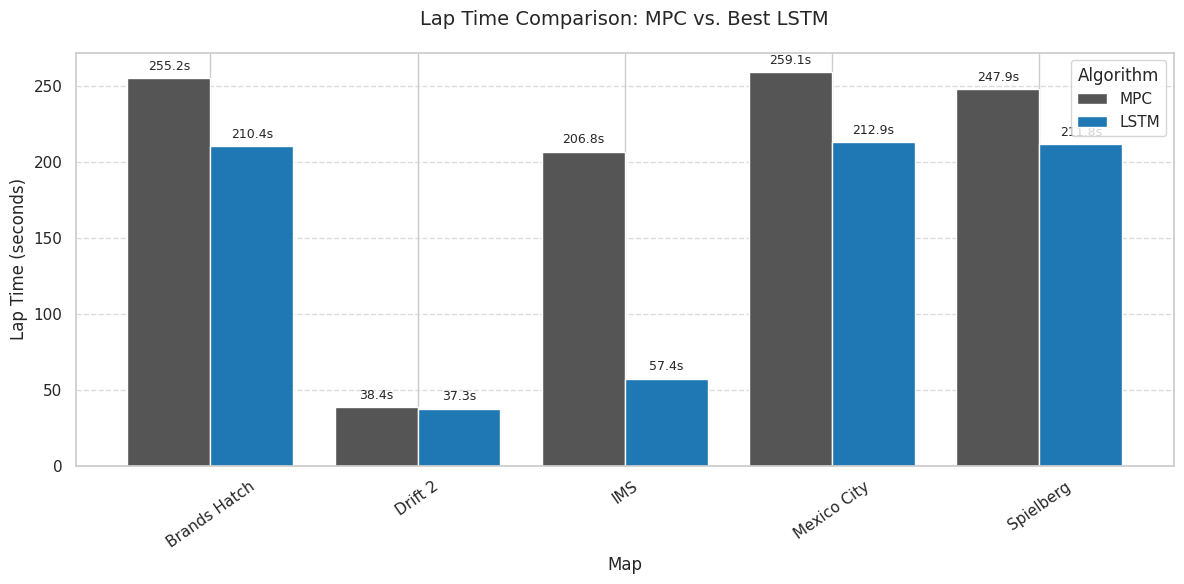

In [8]:
fig, ax = plt.subplots(figsize=(12, 6))
plot_df = comparison_df.set_index("map_display")[["MPC", "LSTM"]]
plot_df.plot(kind="bar", width=0.8, color=["#555555", "#1f77b4"], ax=ax)

ax.set_title("Lap Time Comparison: MPC vs. Best LSTM", fontsize=14, pad=20)
ax.set_ylabel("Lap Time (seconds)")
ax.set_xlabel("Map")
ax.tick_params(axis="x", rotation=35)
ax.grid(axis="y", linestyle="--", alpha=0.7)
ax.legend(title="Algorithm")

for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height):
        ax.annotate(
            f"{height:.1f}s",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom",
            xytext=(0, 4),
            textcoords="offset points",
            fontsize=9,
        )

plt.tight_layout()
plt.show()


In [9]:
mpc_baselines = (
    successful_runs[successful_runs["algorithm"] == "MPC"]
    .set_index("map_norm")["lap_time"]
    .to_dict()
)

lstm_success = successful_runs[successful_runs["algorithm"] == "LSTM"].copy()
lstm_success["mpc_baseline"] = lstm_success["map_norm"].map(mpc_baselines)
lstm_success["percent_improvement"] = (
    (lstm_success["mpc_baseline"] - lstm_success["lap_time"]) / lstm_success["mpc_baseline"] * 100
)
lstm_success["model_config"] = (
    lstm_success["model_type"].str.title() + " (Size: " + lstm_success["size"].astype("Int64").astype(str) + ")"
)

print("Detailed LSTM performance against matched MPC baseline")
display(
    lstm_success[
        ["map_display", "model_config", "lap_time", "mpc_baseline", "percent_improvement", "filepath"]
    ].sort_values(["map_display", "percent_improvement"], ascending=[True, False])
)


Detailed LSTM performance against matched MPC baseline


,map_display,model_config,lap_time,mpc_baseline,percent_improvement,filepath
14,Brands Hatch,Curvature (Size: 128),210.385500,255.23,17.570231,/home/henry/Documents/Coursework/f1_16663/exte...
16,Brands Hatch,Curvature (Size: 96),214.769554,255.23,15.852543,/home/henry/Documents/Coursework/f1_16663/exte...
15,Brands Hatch,Curvature (Size: 196),224.443425,255.23,12.062287,/home/henry/Documents/Coursework/f1_16663/exte...
6,Drift 2,Curvature (Size: 196),37.266941,38.38,2.900101,/home/henry/Documents/Coursework/f1_16663/exte...
5,Drift 2,Curvature (Size: 128),42.887895,38.38,-11.745428,/home/henry/Documents/Coursework/f1_16663/exte...
24,IMS,Mapless (Size: 128),57.356373,206.83,72.268833,/home/henry/Documents/Coursework/f1_16663/exte...
8,IMS,Curvature (Size: 96),154.370128,206.83,25.363763,/home/henry/Documents/Coursework/f1_16663/exte...
10,IMS,Curvature (Size: 196),167.690845,206.83,18.923345,/home/henry/Documents/Coursework/f1_16663/exte...
9,IMS,Curvature (Size: 128),188.368457,206.83,8.925950,/home/henry/Documents/Coursework/f1_16663/exte...
17,Mexico City,Curvature (Size: 128),212.937696,259.09,17.813232,/home/henry/Documents/Coursework/f1_16663/exte...


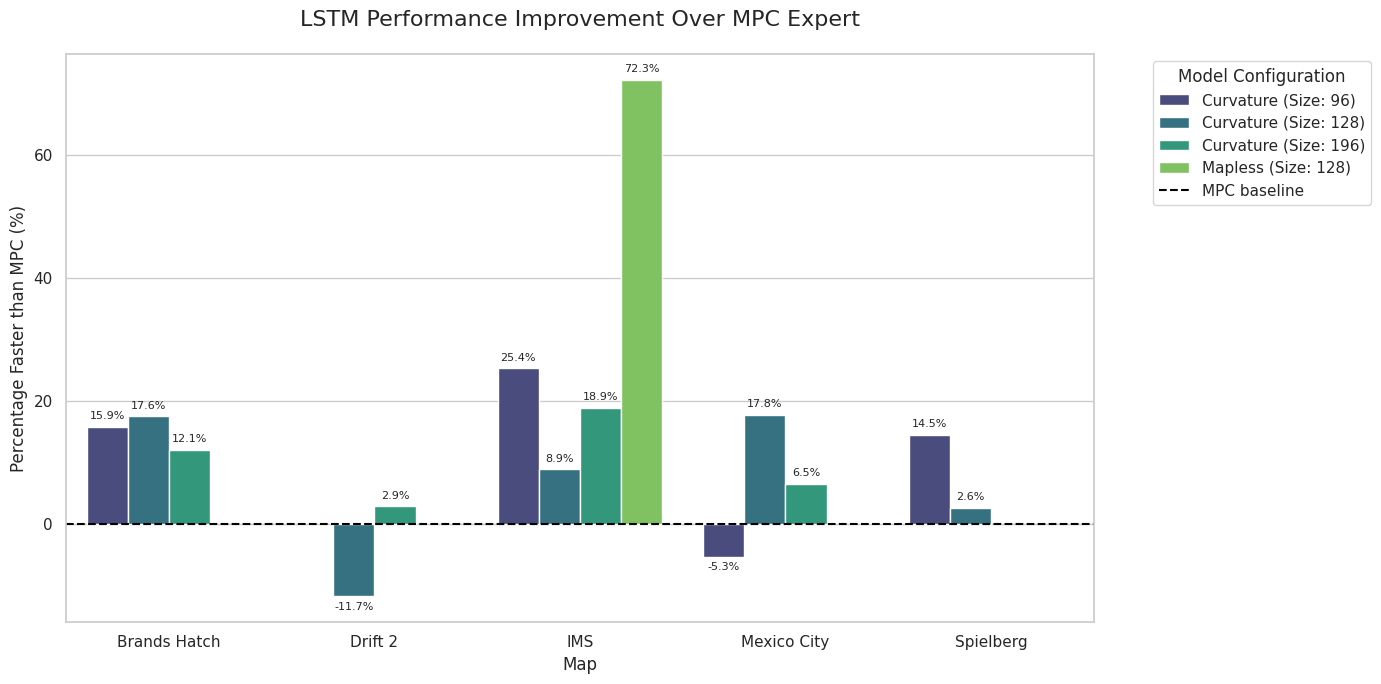

In [10]:
fig, ax = plt.subplots(figsize=(14, 7))

sns.barplot(
    data=lstm_success.sort_values(["map_display", "model_type", "size"]),
    x="map_display",
    y="percent_improvement",
    hue="model_config",
    palette="viridis",
    ax=ax,
)

ax.axhline(0, color="black", linestyle="--", linewidth=1.5, label="MPC baseline")
ax.set_title("LSTM Performance Improvement Over MPC Expert", fontsize=16, pad=20)
ax.set_ylabel("Percentage Faster than MPC (%)")
ax.set_xlabel("Map")
ax.legend(title="Model Configuration", bbox_to_anchor=(1.05, 1), loc="upper left")

for patch in ax.patches:
    height = patch.get_height()
    if np.isfinite(height) and abs(height) > 0:
        ax.annotate(
            f"{height:.1f}%",
            (patch.get_x() + patch.get_width() / 2, height),
            ha="center",
            va="bottom" if height >= 0 else "top",
            xytext=(0, 4 if height >= 0 else -4),
            textcoords="offset points",
            fontsize=8,
        )

plt.tight_layout()
plt.show()


## Raceline Plots


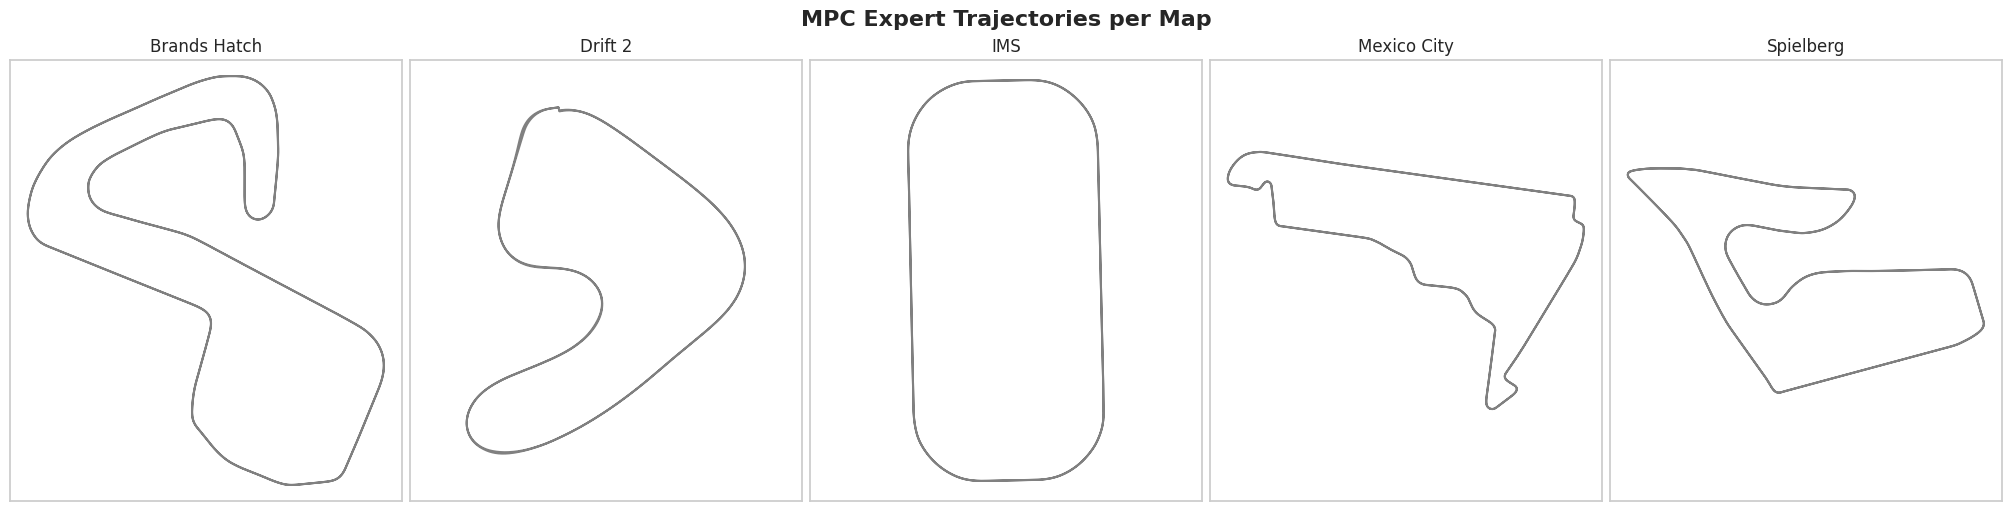

In [11]:
def load_mpc_xy(filepath):
    with np.load(filepath, allow_pickle=True) as data:
        observations = data[get_actual_key(data, "observations")]
    return observations[:, :2]


def load_lstm_xy(filepath):
    with np.load(filepath, allow_pickle=True) as data:
        x = data[get_actual_key(data, "x")]
        y = data[get_actual_key(data, "y")]
    return np.stack([x, y], axis=1)


mpc_runs = successful_runs[successful_runs["algorithm"] == "MPC"].sort_values("map_display")

fig, axes = plt.subplots(1, len(mpc_runs), figsize=(20, 5), constrained_layout=True)
fig.suptitle("MPC Expert Trajectories per Map", fontsize=16, fontweight="bold")

for ax, (_, row) in zip(np.atleast_1d(axes), mpc_runs.iterrows()):
    xy = load_mpc_xy(row["filepath"])
    ax.plot(xy[:, 0], xy[:, 1], color="gray", linewidth=1.5)
    ax.set_title(row["map_display"])
    ax.axis("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, alpha=0.2)

plt.show()


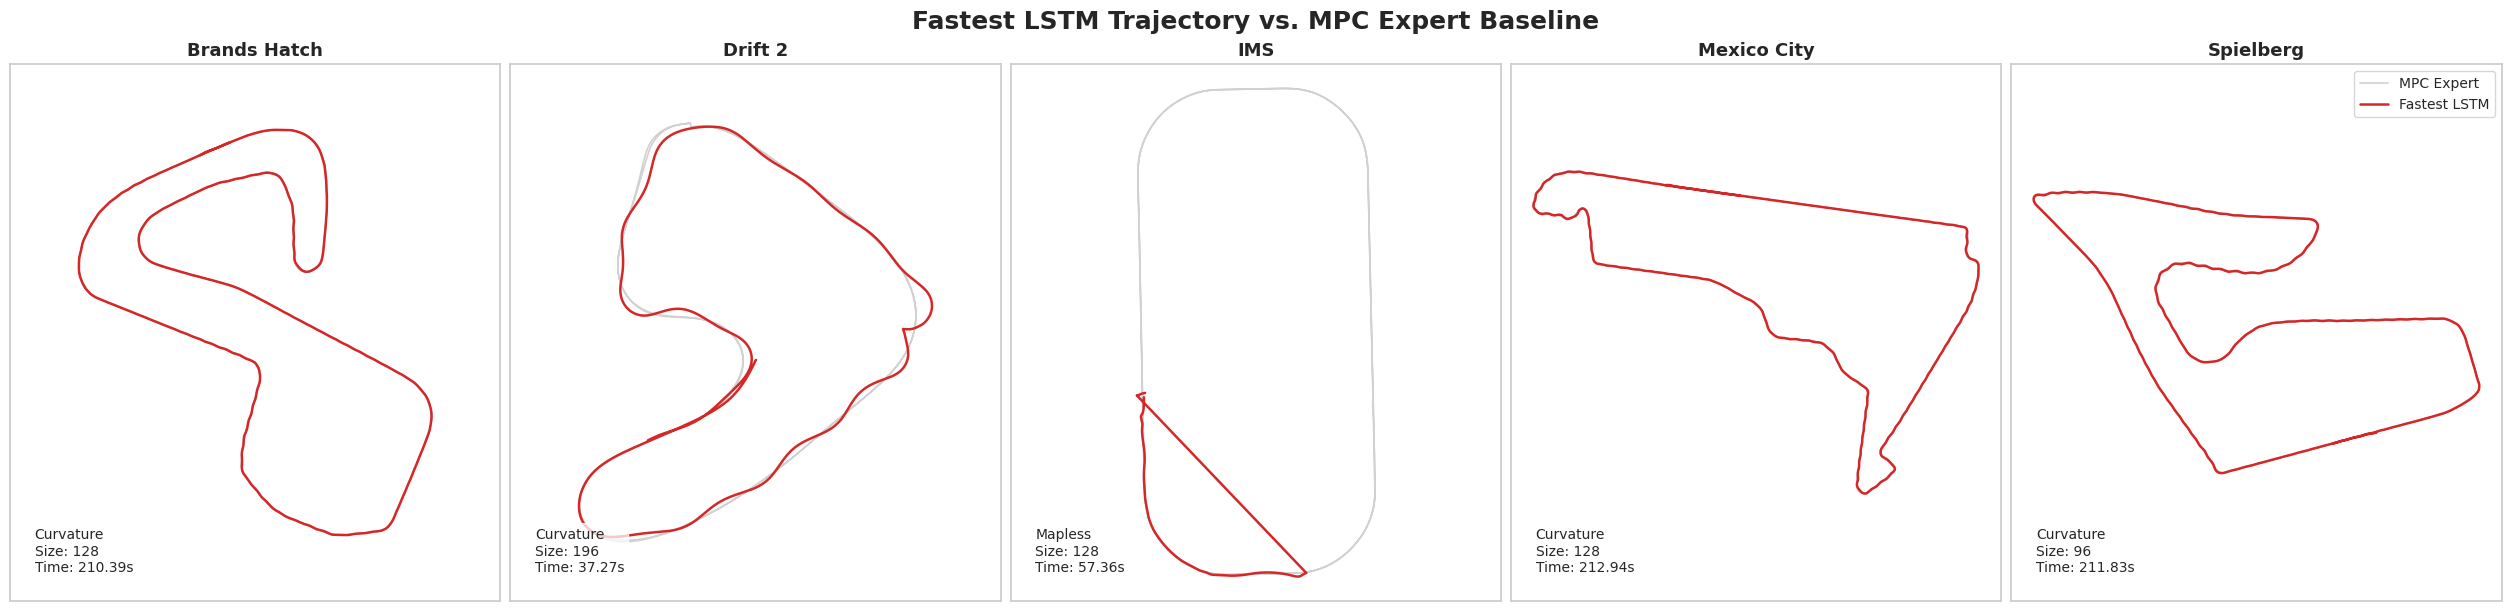

In [12]:
fastest_idx = lstm_success.groupby("map_norm")["lap_time"].idxmin()
fastest_lstms = lstm_success.loc[fastest_idx].sort_values("map_display")

fig, axes = plt.subplots(1, len(fastest_lstms), figsize=(25, 6), constrained_layout=True)
fig.suptitle("Fastest LSTM Trajectory vs. MPC Expert Baseline", fontsize=18, fontweight="bold")

for ax, (_, lstm_row) in zip(np.atleast_1d(axes), fastest_lstms.iterrows()):
    mpc_row = mpc_runs[mpc_runs["map_norm"] == lstm_row["map_norm"]].iloc[0]
    mpc_xy = load_mpc_xy(mpc_row["filepath"])
    lstm_xy = load_lstm_xy(lstm_row["filepath"])

    ax.plot(mpc_xy[:, 0], mpc_xy[:, 1], color="black", alpha=0.18, linewidth=1.2, label="MPC Expert")
    ax.plot(lstm_xy[:, 0], lstm_xy[:, 1], color="#d62728", linewidth=1.8, label="Fastest LSTM")

    model_info = f"{lstm_row['model_type'].title()}\nSize: {int(lstm_row['size'])}\nTime: {lstm_row['lap_time']:.2f}s"
    ax.text(0.05, 0.05, model_info, transform=ax.transAxes, fontsize=10,
            verticalalignment="bottom", bbox=dict(boxstyle="round", facecolor="white", alpha=0.75))

    ax.set_title(lstm_row["map_display"], fontsize=13, fontweight="bold")
    ax.axis("equal")
    ax.set_xticks([])
    ax.set_yticks([])
    ax.grid(True, alpha=0.05)

axes[-1].legend(loc="upper right", fontsize="small")
plt.show()


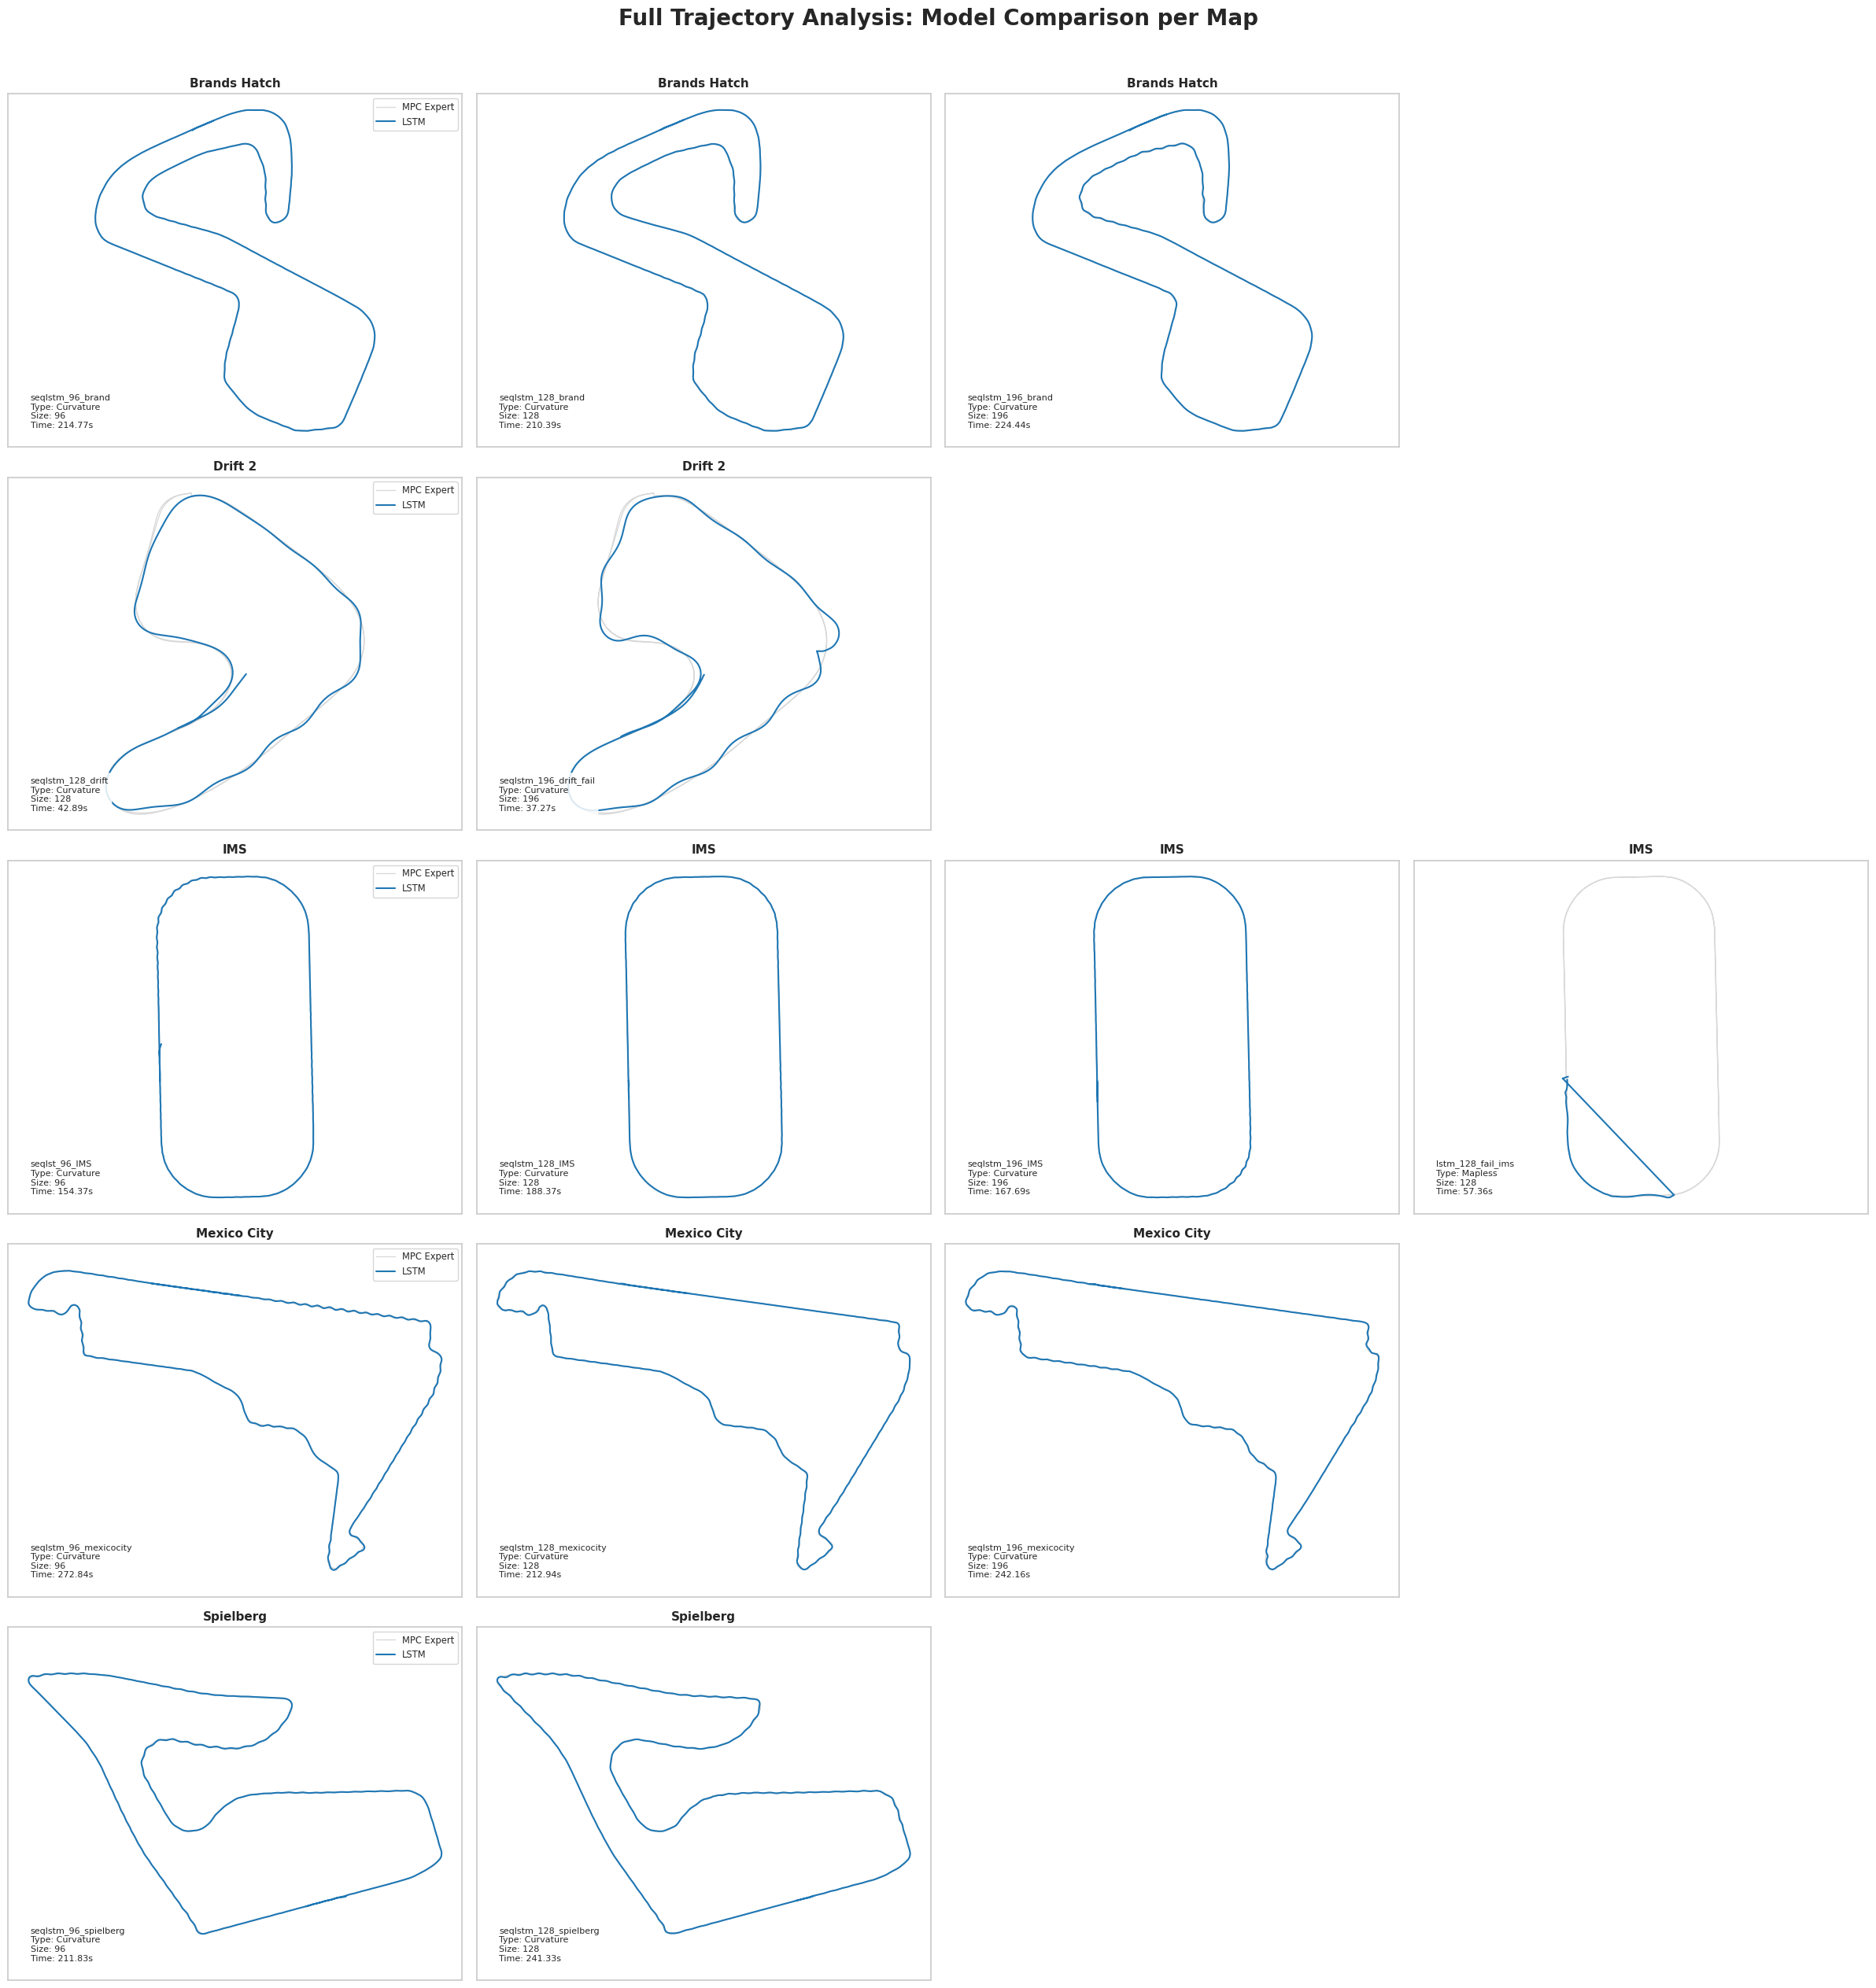

In [13]:
successful_lstms = lstm_success.sort_values(["map_display", "model_type", "size"])
unique_maps = list(successful_lstms["map_norm"].drop_duplicates())
max_models = successful_lstms.groupby("map_norm").size().max()

fig, axes = plt.subplots(len(unique_maps), max_models, figsize=(6 * max_models, 5 * len(unique_maps)), squeeze=False)
fig.suptitle("Full Trajectory Analysis: Model Comparison per Map", fontsize=20, fontweight="bold", y=1.01)

for row_idx, map_norm in enumerate(unique_maps):
    map_subset = successful_lstms[successful_lstms["map_norm"] == map_norm]
    mpc_row = mpc_runs[mpc_runs["map_norm"] == map_norm].iloc[0]
    mpc_xy = load_mpc_xy(mpc_row["filepath"])

    for col_idx in range(max_models):
        ax = axes[row_idx, col_idx]
        if col_idx >= len(map_subset):
            ax.axis("off")
            continue

        lstm_row = map_subset.iloc[col_idx]
        lstm_xy = load_lstm_xy(lstm_row["filepath"])

        ax.plot(mpc_xy[:, 0], mpc_xy[:, 1], color="black", alpha=0.15, linewidth=1, label="MPC Expert")
        ax.plot(lstm_xy[:, 0], lstm_xy[:, 1], color="#1f77b4", linewidth=1.5, label="LSTM")

        model_label = (
            f"{lstm_row['filepath'].stem}\n"
            f"Type: {lstm_row['model_type'].title()}\n"
            f"Size: {int(lstm_row['size'])}\n"
            f"Time: {lstm_row['lap_time']:.2f}s"
        )
        ax.text(0.05, 0.05, model_label, transform=ax.transAxes, fontsize=8,
                verticalalignment="bottom", bbox=dict(boxstyle="round", facecolor="white", alpha=0.85))

        ax.set_title(lstm_row["map_display"], fontsize=11, fontweight="bold")
        ax.axis("equal")
        ax.set_xticks([])
        ax.set_yticks([])
        ax.grid(True, alpha=0.05)
        if col_idx == 0:
            ax.legend(loc="upper right", fontsize="x-small")

plt.tight_layout()
plt.show()


## Raceline Similarity

This is a closest-point distance summary from each LSTM trajectory to the matched MPC trajectory. Lower values indicate that the LSTM path stayed closer to the MPC path spatially, but this metric does not account for direction, progress alignment, or timing.


In [14]:
def closest_point_distance_metrics(lstm_xy, mpc_xy):
    tree = cKDTree(mpc_xy)
    distances, _ = tree.query(lstm_xy, k=1)
    return {
        "mean_closest_dist": float(np.mean(distances)),
        "median_closest_dist": float(np.median(distances)),
        "p95_closest_dist": float(np.percentile(distances, 95)),
        "total_closest_dist": float(np.sum(distances)),
    }

similarity_records = []
for _, lstm_row in lstm_success.iterrows():
    matching_mpc = mpc_runs[mpc_runs["map_norm"] == lstm_row["map_norm"]]
    if matching_mpc.empty:
        continue

    mpc_row = matching_mpc.iloc[0]
    try:
        metrics = closest_point_distance_metrics(load_lstm_xy(lstm_row["filepath"]), load_mpc_xy(mpc_row["filepath"]))
    except Exception as exc:
        print(f"Error processing {lstm_row['filepath']}: {exc}")
        continue

    similarity_records.append({
        "map_display": lstm_row["map_display"],
        "lstm_model": lstm_row["model_type"],
        "lstm_size": int(lstm_row["size"]),
        "lstm_lap_time": lstm_row["lap_time"],
        "mpc_lap_time": mpc_row["lap_time"],
        **metrics,
    })

sim_df = pd.DataFrame(similarity_records).sort_values(["map_display", "mean_closest_dist"])
print("Raceline similarity table")
display(sim_df)


Raceline similarity table


,map_display,lstm_model,lstm_size,lstm_lap_time,mpc_lap_time,mean_closest_dist,median_closest_dist,p95_closest_dist,total_closest_dist
7,Brands Hatch,curvature,128,210.385500,255.23,0.032402,0.025072,0.090382,404.609166
9,Brands Hatch,curvature,96,214.769554,255.23,0.032635,0.019306,0.118864,455.098713
8,Brands Hatch,curvature,196,224.443425,255.23,0.054044,0.024420,0.189490,780.930040
1,Drift 2,curvature,196,37.266941,38.38,0.246021,0.202031,0.478990,1248.062961
0,Drift 2,curvature,128,42.887895,38.38,0.286294,0.127828,0.701758,1399.406809
3,IMS,curvature,128,188.368457,206.83,0.030063,0.023678,0.086224,360.515104
4,IMS,curvature,196,167.690845,206.83,0.033007,0.023165,0.108357,391.298319
2,IMS,curvature,96,154.370128,206.83,0.053015,0.042009,0.130836,633.163256
13,IMS,mapless,128,57.356373,206.83,0.260801,0.268844,0.674860,1679.295207
10,Mexico City,curvature,128,212.937696,259.09,0.044360,0.026777,0.148372,646.761906


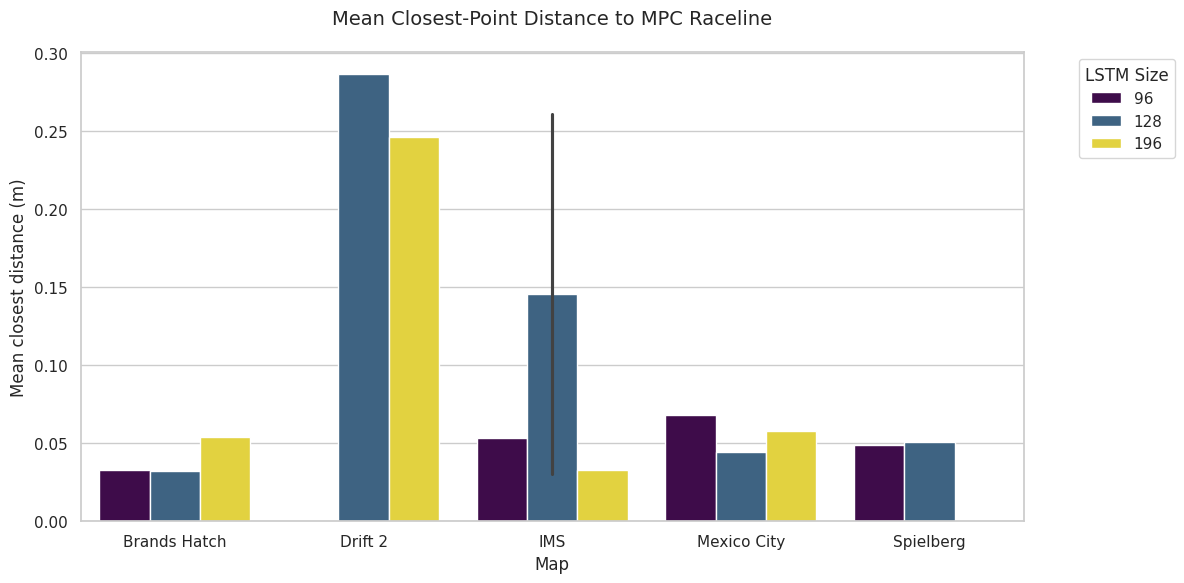

In [15]:
fig, ax = plt.subplots(figsize=(12, 6))

sns.barplot(
    data=sim_df,
    x="map_display",
    y="mean_closest_dist",
    hue="lstm_size",
    palette="viridis",
    ax=ax,
)

ax.set_title("Mean Closest-Point Distance to MPC Raceline", fontsize=14, pad=20)
ax.set_ylabel("Mean closest distance (m)")
ax.set_xlabel("Map")
ax.legend(title="LSTM Size", bbox_to_anchor=(1.05, 1), loc="upper left")
plt.tight_layout()
plt.show()
